## Problem statement:
In the fast faced taxi booking sector making the most of revenue is essential for long term success and driver happiness 
Our goal is to use the data driven insight to maximize the revenue stream for taxi drivers in order to meet this need or our research aim 
to determine whether payment methods have an impact or fair pricing by focusing on the relationship between payment type and fare amount

## Research question:
is there any relationship between total fair amount and the payment type? Can we nudge customers towards the payment method that generate higher revenue for drivers, without negatively impacting customer experience?

## Objective 
This project's main goal is to run an A or B testing to examine the relationship between the total fare and the method of payment we use Python hypothesis testing and descriptive statistics to extract the useful information that can help taxi drivers generate more cash. In particular, we want to find out if there is a big difference in a fair for those who pay with credit cards versus those who pay with cash

### Import Libraries

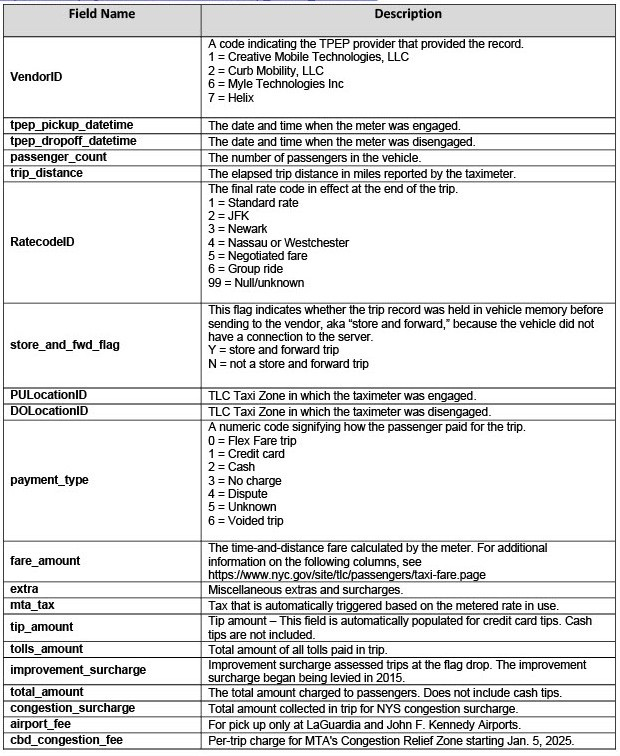

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as st
import warnings
import statsmodels.api as sm
warnings.filterwarnings('ignore')

### Load the Dataset

In [50]:
df=pd.read_parquet('yellow_tripdata_2025-01.parquet')

In [51]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


### Exploratory Data Analysis

In [52]:
df.shape

(3475226, 20)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

There are so many columns in the data set, but as per our problem statement, we only require some field from the original data. Next columns are nothing but the unwanted columns for this study so we'll simply remove these columns.

As per the problem statement is revolving around the payment types, fair amount, and any other factor influencing the fair amount, we will filter the data to have only passenger count, tips distance, payment type, fare amount and duration of the trips.

In [54]:
df['tpep_pickup_datetime']=pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime']=pd.to_datetime(df['tpep_dropoff_datetime'])

In [55]:
df['Duration']=df['tpep_dropoff_datetime']-df['tpep_pickup_datetime']
df['Duration']=df['Duration'].dt.total_seconds()/60

In [56]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,Duration
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,...,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.00,8.350000
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,...,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.00,2.550000
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,...,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.00,1.950000
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,...,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.00,5.566667
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,...,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.00,3.533333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3475221,2,2025-01-31 23:01:48,2025-01-31 23:16:29,NaN,3.35,NaN,None,79,237,0,...,0.0,0.5,0.00,0.0,1.0,20.60,NaN,NaN,0.75,14.683333
3475222,2,2025-01-31 23:50:29,2025-02-01 00:17:27,NaN,8.73,NaN,None,161,116,0,...,0.0,0.5,0.00,0.0,1.0,32.89,NaN,NaN,0.75,26.966667
3475223,2,2025-01-31 23:26:59,2025-01-31 23:43:01,NaN,2.64,NaN,None,144,246,0,...,0.0,0.5,0.00,0.0,1.0,19.66,NaN,NaN,0.75,16.033333
3475224,2,2025-01-31 23:14:34,2025-01-31 23:34:52,NaN,3.16,NaN,None,142,107,0,...,0.0,0.5,0.00,0.0,1.0,22.30,NaN,NaN,0.75,20.300000


In [57]:
# filtered data with Relevent columns essential for the analysis
df=df[['passenger_count','payment_type','fare_amount','trip_distance','Duration']]
df

,passenger_count,payment_type,fare_amount,trip_distance,Duration
0,1.0,1,10.00,1.60,8.350000
1,1.0,1,5.10,0.50,2.550000
2,1.0,1,5.10,0.60,1.950000
3,3.0,2,7.20,0.52,5.566667
4,3.0,2,5.80,0.66,3.533333
...,...,...,...,...,...
3475221,NaN,0,15.85,3.35,14.683333
3475222,NaN,0,28.14,8.73,26.966667
3475223,NaN,0,14.91,2.64,16.033333
3475224,NaN,0,17.55,3.16,20.300000


In [10]:
# Check for missing Values
df.isnull().sum()

passenger_count    540149
payment_type            0
fare_amount             0
trip_distance           0
Duration                0
dtype: int64

In [11]:
# % of missing data to the total record of the data
print("Missing Data % ",round(244892/df.shape[0]*100,2))

Missing Data %  7.05


In [12]:
# filling the null values 
df['passenger_count']=df['passenger_count'].fillna(df['passenger_count'].mean())

In [13]:
# Converting the data Type
df['passenger_count']=df['passenger_count'].astype('int64')
df['payment_type']=df['payment_type'].astype('int64')

In [14]:
# check for Duplicates
df[df.duplicated()]

,passenger_count,payment_type,fare_amount,trip_distance,Duration
1266,1,1,7.20,0.90,5.133333
2154,1,1,9.30,1.50,8.616667
2677,2,1,5.10,0.44,2.583333
2739,1,1,10.00,1.45,8.316667
3469,1,1,11.40,1.98,9.083333
...,...,...,...,...,...
3475143,1,0,-4.75,2.54,12.000000
3475181,1,0,-4.75,2.34,13.983333
3475196,1,0,-4.75,2.28,13.700000
3475204,1,0,-4.75,2.55,13.266667


In [15]:
# Removing the duplicates
df.drop_duplicates(inplace=True)

In [16]:
# passenger Count Distribution 
df['passenger_count'].value_counts(normalize=True)

passenger_count
1    0.770885
2    0.142937
3    0.038132
4    0.025485
0    0.009312
5    0.007887
6    0.005353
8    0.000005
7    0.000002
9    0.000001
Name: proportion, dtype: float64

In [17]:
# Payment type Distribution 
df['payment_type'].value_counts(normalize=True)

payment_type
1    5.830191e-01
0    2.361379e-01
2    1.402442e-01
4    3.164858e-02
3    8.949806e-03
5    4.522388e-07
Name: proportion, dtype: float64

So we will focus solely on the payment types Flex,card and cash denoted by 0, 1 and 2 in the dataset. to ensure our analysis centers on these payment methods we will filter the data accordingly excluding all other types.

Moreover, examining the distribution of passenger counts reveals the with more than five passenger are rare additionally, trips with zero passenger are impossible as we expect at least one passenger to pay the fare amount therefore, we will filter the passenger phone to include only value range from one to 5

In [18]:
#Filtering the Pyment types for 0,1 and 2
df=df[df['payment_type']<3]
#Filtering the passenger count  form 1 to 5
df=df[(df['passenger_count']>0) & (df['passenger_count']<6)]

In [19]:
# Replacing the payment type encoded Value 0,1 and 2 to Flex, card and cash
df['payment_type'].replace([0,1,2],['flex','Card','Cash'],inplace=True)

In [20]:
df['payment_type'].value_counts()

payment_type
Card    1263187
flex     522153
Cash     304386
Name: count, dtype: int64

In [21]:
# Discriptive Statistics for data
df.describe()

,passenger_count,fare_amount,trip_distance,Duration
count,2.089726e+06,2.089726e+06,2.089726e+06,2.089726e+06
mean,1.330701e+00,2.162147e+01,8.751565e+00,1.882588e+01
std,7.413097e-01,1.986782e+01,7.280805e+02,3.299237e+01
min,1.000000e+00,-7.000000e+02,0.000000e+00,-5.603333e+01
25%,1.000000e+00,1.070000e+01,1.330000e+00,9.933333e+00
50%,1.000000e+00,1.630000e+01,2.390000e+00,1.535000e+01
75%,1.000000e+00,2.599000e+01,4.730000e+00,2.266667e+01
max,5.000000e+00,2.450900e+03,2.764236e+05,5.626317e+03


Upon reviewing the provided statistics, it's evident that the minimum value for the trip distance, fair amount, and duration are negative, which is unrealistic and invalid for the further analysis Consequently, we will eliminate these negative values from the dataset. 

furthermore, observing the maximum 50th percentile values, it's possible that the data contains significant outliers, particularly high values. These our players need to be addressed and removed to ensure the integrity of the analysis

In [22]:
# filtering the Records  for only Positive Values
df=df[df['fare_amount']>0]
df=df[df['trip_distance']>0]
df=df[df['Duration']>0]

{'whiskers': [<matplotlib.lines.Line2D at 0x2188004d4f0>,
 'caps': [<matplotlib.lines.Line2D at 0x2188004da00>,
 'boxes': [<matplotlib.lines.Line2D at 0x2188004d250>],
 'medians': [<matplotlib.lines.Line2D at 0x2188004e000>],
 'fliers': [<matplotlib.lines.Line2D at 0x2188004e2a0>],
 'means': []}

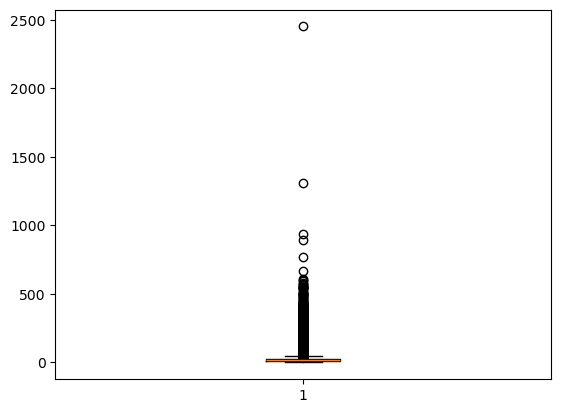

In [23]:
plt.boxplot(df['fare_amount'])

In [24]:
# To Remove outliers i will use inter Quartile range
for col in ['fare_amount','trip_distance','Duration']:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    IQR=q3-q1

    lower_bound=q1-1.5*IQR
    upper_bound=q3+1.5*IQR

    df=df[(df[col]>=lower_bound)&(df[col]<=upper_bound)]



I am interested on exploring the relationship between payment type and the passenger behavior concerning tip trips distance and the fare amount are the variation in the distribution of the payment type concerning different fair amount of trip distance. 

To investigating this, we will plot histogram to visualize the distribution of the passenger count playing with their flex card or cash. This will also provide stakeholders with the insights into the fair amount range ranges associated with the different payment methods

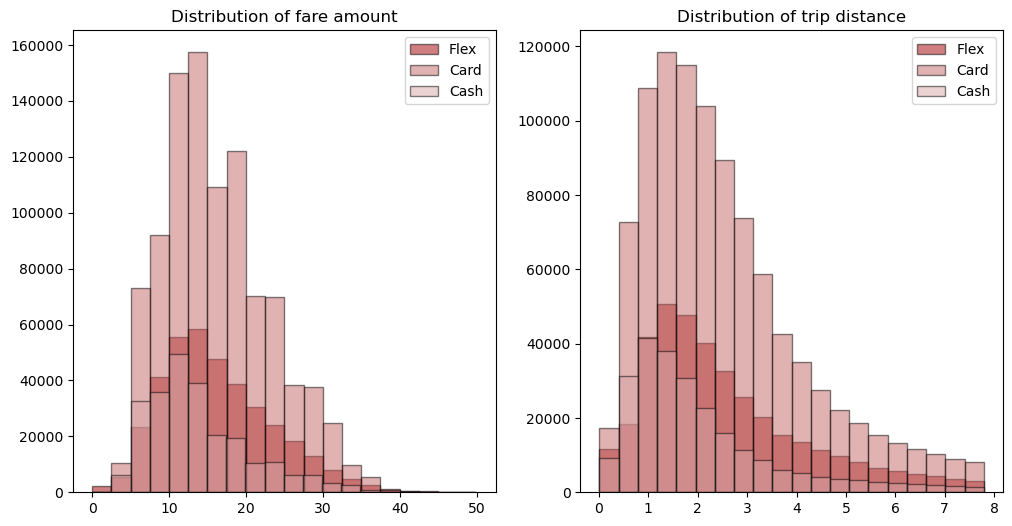

In [25]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Distribution of fare amount')
plt.hist(df[df['payment_type']=='flex']['fare_amount'],histtype='barstacked',bins=20,edgecolor='k',color='#a00000',alpha=0.5,label='Flex')
plt.hist(df[df['payment_type']=='Card']['fare_amount'],histtype='barstacked',bins=20,edgecolor='k',color='#c46666',alpha=0.5,label='Card')
plt.hist(df[df['payment_type']=='Cash']['fare_amount'],histtype='barstacked',bins=20,edgecolor='k',color='#d8a6a6',alpha=0.5,label='Cash')
plt.legend()


plt.subplot(1,2,2)
plt.title('Distribution of trip distance')
plt.hist(df[df['payment_type']=='flex']['trip_distance'],histtype='barstacked',bins=20,edgecolor='k',color='#a00000',alpha=0.5,label='Flex')
plt.hist(df[df['payment_type']=='Card']['trip_distance'],histtype='barstacked',bins=20,edgecolor='k',color='#c46666',alpha=0.5,label='Card')
plt.hist(df[df['payment_type']=='Cash']['trip_distance'],histtype='barstacked',bins=20,edgecolor='k',color='#d8a6a6',alpha=0.5,label='Cash')
plt.legend()
plt.show()



In [26]:

df.groupby('payment_type').agg({'fare_amount':['mean','std'],'trip_distance':['mean','std']})

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
Card           16.228249  6.918460      2.519253  1.607401
Cash           13.804098  6.707306      2.035894  1.534791
flex           16.304114  7.188216      2.541962  1.647897

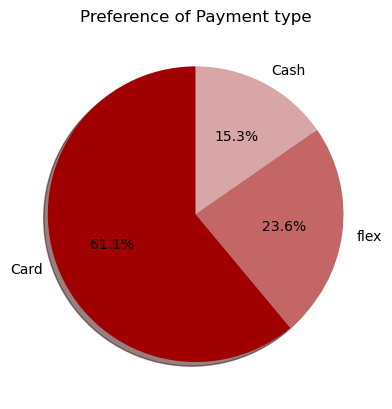

In [27]:
plt.title('Preference of Payment type')
plt.pie(df['payment_type'].value_counts(normalize=True),labels=df['payment_type'].value_counts().index,
        startangle=90,shadow=True,autopct='%1.1f%%',colors=['#a00000','#c46666','#d8a6a6'])
plt.show()

In [28]:
passenger_count=df.groupby(['payment_type','passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns={'passenger_count':'count'},inplace=True)
passenger_count.reset_index(inplace=True)

In [29]:
passenger_count['perc']=(passenger_count['count']/passenger_count['count'].sum())*100

In [30]:
passenger_count

,payment_type,passenger_count,count,perc
0,Card,1,671156,42.154651
1,Card,2,197985,12.435244
2,Card,3,56407,3.542868
3,Card,4,33240,2.087772
4,Card,5,13271,0.833539
5,Cash,1,177929,11.175546
6,Cash,2,43052,2.704054
7,Cash,3,11481,0.721110
8,Cash,4,9407,0.590844
9,Cash,5,2317,0.145529


In [31]:
df_p = passenger_count.pivot(
    index='payment_type',
    columns='passenger_count',
    values='perc'
).fillna(0)

df_p = df_p.reset_index()
df_p

passenger_count,payment_type,1,2,3,4,5
0,Card,42.154651,12.435244,3.542868,2.087772,0.833539
1,Cash,11.175546,2.704054,0.721110,0.590844,0.145529
2,flex,23.608843,0.000000,0.000000,0.000000,0.000000


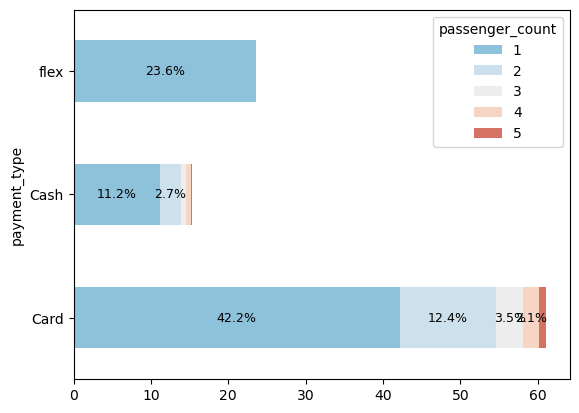

In [32]:

ax=df_p.plot(x='payment_type',kind='barh',stacked=True, color =['#8ec1da','#cde1ec','#ededed','#f6d6c2','#d47264'])

# adding percentage text
for p in ax.patches:
    width = p.get_width()
    
    # skip very small values (avoid clutter)
    if width > 1:
        x, y = p.get_xy()
        ax.text(x + width/2,
                y + p.get_height()/2,
                f'{width:.1f}%',
                ha='center',
                va='center',
                fontsize=9,
                color='black')

**Null hypothesis** : Passenger count distribution is same across all payment types

**Alternative hypothesis** :Passenger count distribution differs by payment type

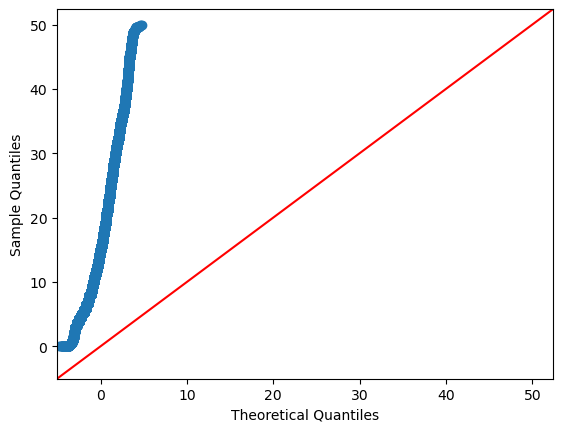

In [33]:
sm.qqplot(df['fare_amount'],line='45')
plt.show()

In [42]:
df['payment_type'] =df['payment_type'].str.lower()

In [44]:
flex_sample = df[df['payment_type']=='flex']['fare_amount'].dropna()
card_sample = df[df['payment_type']=='card']['fare_amount'].dropna()
cash_sample = df[df['payment_type']=='cash']['fare_amount'].dropna()

In [46]:
f_stat, p_value = st.f_oneway(flex_sample, card_sample, cash_sample)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 12807.113304649045
p-value: 0.0


I performed a One-Way ANOVA to test whether fare amounts differ across payment types.
The p-value was effectively zero, so I rejected the null hypothesis, indicating a statistically significant difference.